In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the ground truth data
df = pd.read_csv("../../data/datasets/london_rentals_random.csv")

# Quick look
print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_type     1000 non-null   str    
 1   n_rooms           1000 non-null   int64  
 2   dist_centre_km    1000 non-null   float64
 3   outdoor_space     1000 non-null   str    
 4   near_underground  1000 non-null   int64  
 5   intercept         1000 non-null   float64
 6   beta_prop         1000 non-null   float64
 7   beta_room         1000 non-null   float64
 8   beta_dist         1000 non-null   float64
 9   beta_outdoor      1000 non-null   float64
 10  beta_under        1000 non-null   float64
 11  premium           1000 non-null   float64
 12  monthly_rent_gbp  1000 non-null   float64
 13  listing_type      1000 non-null   str    
dtypes: float64(9), int64(2), str(3)
memory usage: 125.1 KB
None


,property_type,n_rooms,dist_centre_km,outdoor_space,near_underground,intercept,beta_prop,beta_room,beta_dist,beta_outdoor,beta_under,premium,monthly_rent_gbp,listing_type
0,Flat,4,2.191222,Nothing,0,7.514901,0.000000,0.160352,-0.055014,0.00000,0.000000,0.0,3482.235341,Owner
1,House,5,7.575474,Nothing,0,7.495852,0.247959,0.154579,-0.045599,0.00000,0.000000,0.0,3448.296661,Owner
2,Flat,5,4.149337,Nothing,1,7.519431,0.000000,0.139818,-0.013805,0.00000,0.136012,0.0,5188.841209,Owner
3,Flat,4,1.513386,Garden,0,7.545691,0.000000,0.258391,-0.074508,0.15208,0.000000,0.0,5241.364385,Owner
4,Flat,2,5.936449,Nothing,0,7.492975,0.000000,0.157131,-0.038940,0.00000,0.000000,0.0,2119.278223,Owner


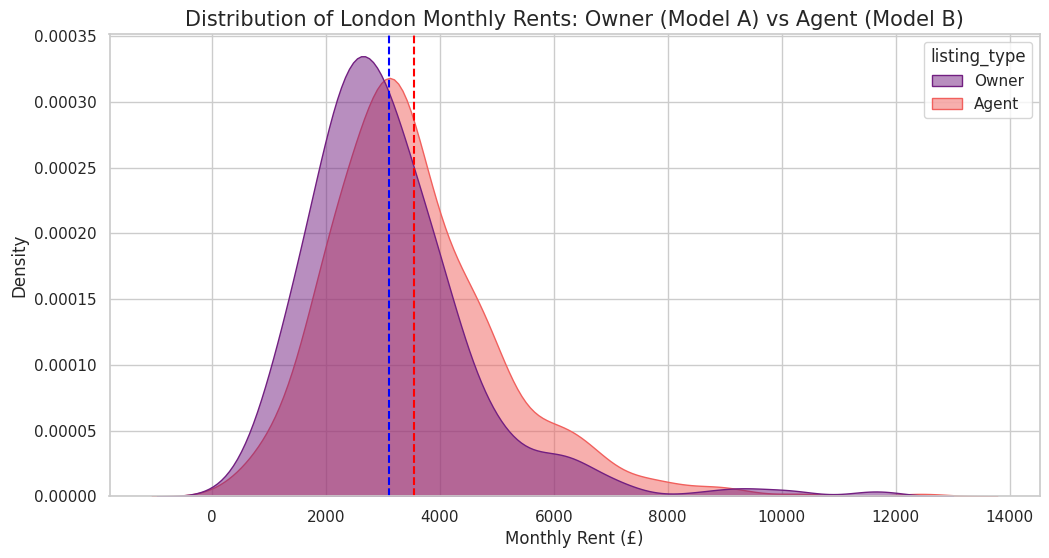

                     mean       median          std  count  markup_percent
listing_type                                                              
Agent         3542.517864  3274.009561  1547.717895    500       14.152984
Owner         3103.307275  2890.265697  1518.345969    500       14.152984


In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot the distribution of prices for Owners vs Agents
sns.kdeplot(data=df, x='monthly_rent_gbp', hue='listing_type', 
            fill=True, common_norm=False, palette='magma', alpha=0.5)

plt.title('Distribution of London Monthly Rents: Owner (Model A) vs Agent (Model B)', fontsize=15)
plt.xlabel('Monthly Rent (£)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(df[df['listing_type']=='Owner']['monthly_rent_gbp'].mean(), color='blue', linestyle='--', label='Owner Mean')
plt.axvline(df[df['listing_type']=='Agent']['monthly_rent_gbp'].mean(), color='red', linestyle='--', label='Agent Mean')
# plt.legend()
plt.show()

# Summary statistics to quantify the gap
summary = df.groupby('listing_type')['monthly_rent_gbp'].agg(['mean', 'median', 'std', 'count'])
summary['markup_percent'] = (summary.loc['Agent', 'mean'] / summary.loc['Owner', 'mean'] - 1) * 100
print(summary)

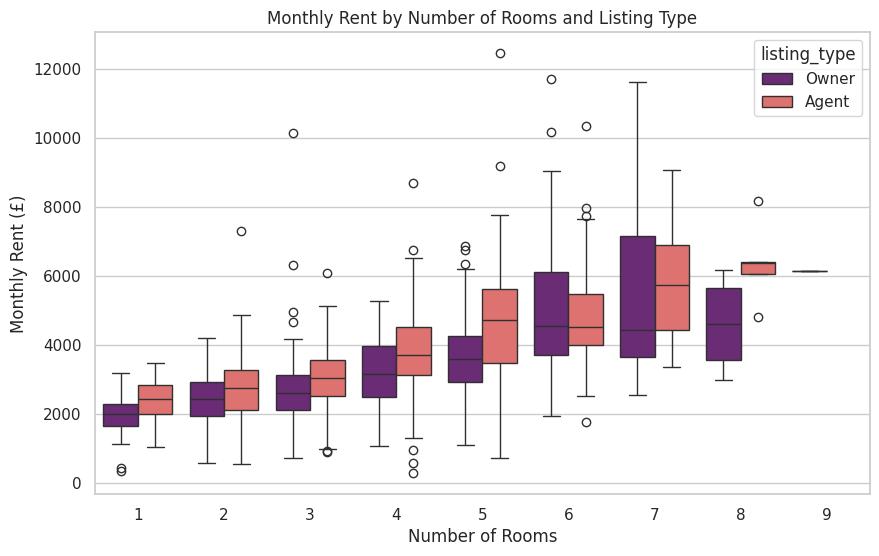

In [3]:
plt.figure(figsize=(10, 6))

# Boxplot showing price distribution per room count, split by listing type
sns.boxplot(data=df, x='n_rooms', y='monthly_rent_gbp', hue='listing_type', palette='magma')

plt.title('Monthly Rent by Number of Rooms and Listing Type')
plt.xlabel('Number of Rooms')
plt.ylabel('Monthly Rent (£)')
plt.show()

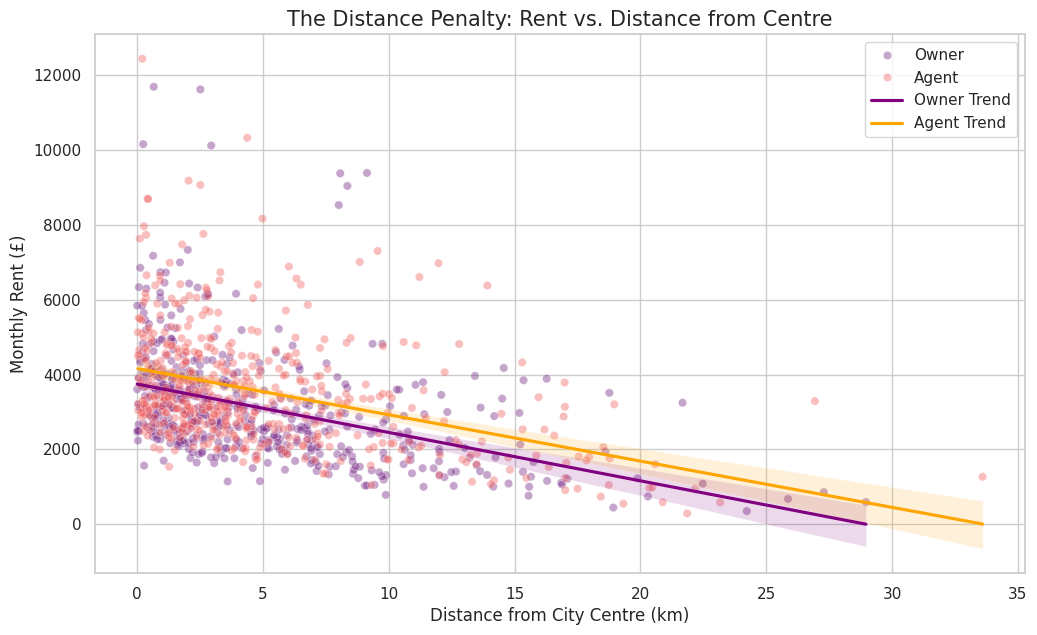

In [4]:
plt.figure(figsize=(12, 7))

# Scatter plot with a trend line (regression) for each listing type
sns.scatterplot(data=df, x='dist_centre_km', y='monthly_rent_gbp', 
                hue='listing_type', palette='magma', alpha=0.4)

# Adding regression lines to see the "slope" of the price drop
sns.regplot(data=df[df['listing_type']=='Owner'], x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='purple', label='Owner Trend')
sns.regplot(data=df[df['listing_type']=='Agent'], x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='orange', label='Agent Trend')

plt.title('The Distance Penalty: Rent vs. Distance from Centre', fontsize=15)
plt.xlabel('Distance from City Centre (km)', fontsize=12)
plt.ylabel('Monthly Rent (£)', fontsize=12)
plt.legend()
plt.show()

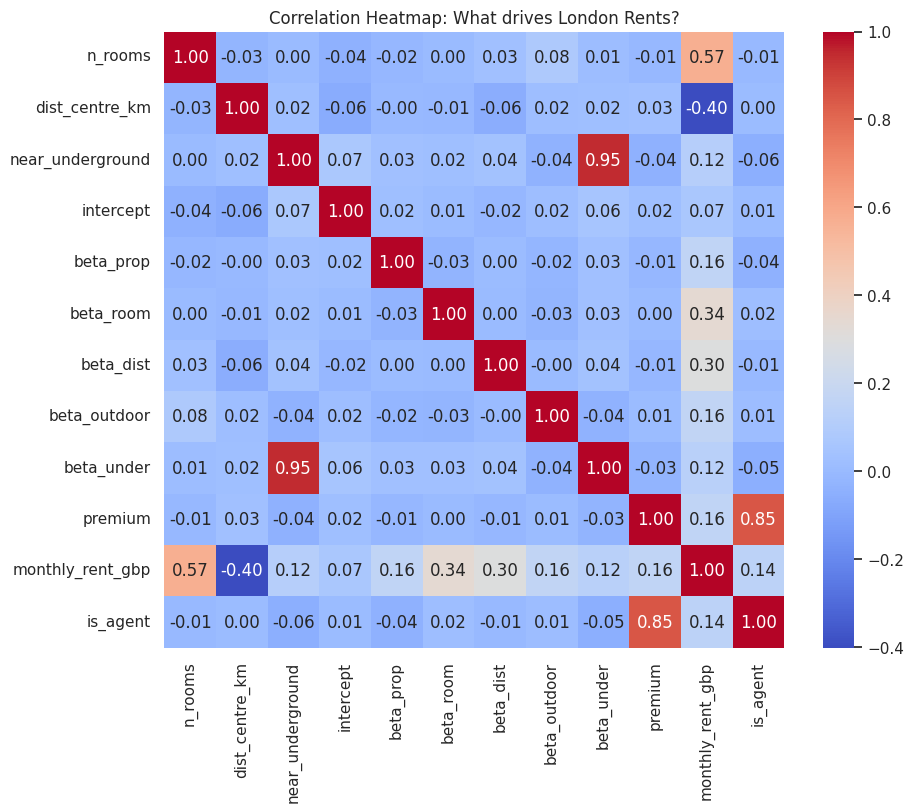

In [5]:
# Convert listing_type to numeric for correlation check
df_corr = df.copy()
df_corr['is_agent'] = (df['listing_type'] == 'Agent').astype(int)

# Select only numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
correlation_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: What drives London Rents?')
plt.show()